# Check data for the spatial transcriptome dataset

Data source: http://zhuang.harvard.edu/merfish.html. 

# 1) Check image and count data

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import re
import skimage
import skimage.io
import skimage.transform
import tifffile

In [4]:
fish_file = "./Sample_data/Dataset_MERFISH/Moffitt_and_Bambah-Mukku_et_al_merfish_all_cells.csv"
fish_pd = pd.read_csv(fish_file)
print(fish_pd.shape)
fish_pd

(1027848, 170)


,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,Ace2,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
0,6749ccb4-2ed1-4029-968f-820a287f43c8,1,Female,Naive,0.26,-3211.562145,2608.541476,Astrocyte,NaN,0.0,...,0.133016,0.000000,0.865263,0.002977,0.054826,0.008934,0.000000,0.000000,0.000000,0.000000
1,6cac74bd-4ea7-4701-8701-42563cc65eb8,1,Female,Naive,0.26,-3207.923151,2621.795437,Inhibitory,I-5,0.0,...,0.000000,0.000000,0.277939,0.868702,0.580957,0.010079,0.000000,0.000000,0.000000,0.000000
2,9f29bd57-16a5-4b26-b9f5-37598809da9e,1,Female,Naive,0.26,-3209.578004,2633.153494,Inhibitory,I-6,0.0,...,0.213939,0.000000,0.377907,0.049332,0.084898,0.008951,0.000000,0.000000,0.000000,0.000000
3,d7eb4e0b-276e-47e3-a55c-0b033180a2fe,1,Female,Naive,0.26,-3203.853515,2756.045983,Inhibitory,I-5,0.0,...,0.050882,0.089038,0.000000,0.000000,0.001530,0.031364,0.000000,0.000000,0.000000,0.001138
4,54434f3a-eba9-4aec-af35-c9d317ffa1d5,1,Female,Naive,0.26,-3202.682705,2608.803635,Inhibitory,I-9,0.0,...,1.250661,0.159618,0.211159,0.000000,0.087730,0.000000,0.000000,0.000000,0.000000,0.029419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1027843,eaaf93ba-75b1-40cd-af08-a4d803511354,30,Male,Mating,0.11,2732.438894,-2322.578167,Ambiguous,NaN,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.040998,0.000000,0.000000,0.024618,0.000000
1027844,bb9caf59-d960-452e-a9fd-9238ce5e44ca,30,Male,Mating,0.11,2732.665807,-2120.226450,Ambiguous,NaN,0.0,...,0.000000,0.852081,0.000000,0.695548,0.000000,0.024392,0.475944,0.000000,0.000000,0.000000
1027845,2f45d61d-3a80-470b-8cb8-251a2c8d2e59,30,Male,Mating,0.11,2826.247461,-2308.947366,Ambiguous,NaN,0.0,...,0.058011,0.000000,0.000000,0.000000,0.000000,0.061898,0.000000,0.000000,0.000000,0.000000
1027846,180ae0ff-9817-48b9-8d34-b374bda6e316,30,Male,Mating,0.11,2900.963778,-2174.600160,Inhibitory,I-2,0.0,...,0.000000,0.326172,0.000000,0.000000,0.000000,0.063518,0.000000,0.000000,0.000000,0.000000


In [4]:
for animal_id in range(1, 31):
    fish_pd_sub = fish_pd.loc[fish_pd['Animal_ID'] == animal_id, :]
    print(animal_id, fish_pd_sub.shape)
    print(set(fish_pd_sub['Bregma'].values))
    for bregma in list(set(fish_pd_sub['Bregma'].values)):
        print(bregma, np.sum(fish_pd_sub['Bregma'].values == bregma))
        '''
        plt.figure(figsize=(8, 8))
        _fish_pd_sub = fish_pd.loc[np.logical_and(fish_pd['Animal_ID'] == animal_id, fish_pd['Bregma'] == bregma), :]
        sns.scatterplot(_fish_pd_sub['Centroid_X'], _fish_pd_sub['Centroid_Y'], hue=_fish_pd_sub['Cell_class'], palette='tab20')
        plt.show()
        '''
        
# For animal_id == 18, bregma_id == 0.11: n_cells = 5665
# For animal_id == 18, bregma_id == 0.26: n_cells = 5555

1 (73655, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, -0.09, -0.14, -0.19, -0.24, -0.29, 0.01, -0.04}
0.26 5584
0.11 5799
0.21 5578
0.06 6144
0.16 6067
-0.09 6185
-0.14 6605
-0.19 6507
-0.24 6412
-0.29 6509
0.01 6111
-0.04 6154
2 (69039, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, -0.09, -0.14, -0.19, -0.24, -0.29, 0.01, -0.04}
0.26 5280
0.11 5727
0.21 5361
0.06 5381
0.16 5284
-0.09 5819
-0.14 6135
-0.19 6328
-0.24 6263
-0.29 6091
0.01 5677
-0.04 5693
3 (34289, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, 0.01}
0.26 5331
0.11 5889
0.21 5451
0.06 6058
0.16 5736
0.01 5824
4 (28365, 170)
{-0.14, -0.19, -0.29, -0.09, -0.04}
-0.14 6036
-0.19 5694
-0.29 6236
-0.09 4689
-0.04 5710
5 (33569, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, 0.01}
0.26 5457
0.11 5765
0.21 5228
0.06 5329
0.16 5839
0.01 5951
6 (31564, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, 0.01}
0.26 4661
0.11 5429
0.21 5285
0.06 5491
0.16 5143
0.01 5555
7 (70498, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, -0.09, -0.14, -0.19, -0.24, -0.29, 0.01, -0.04}
0.26 5905
0.11 6000
0.21

1 (73655, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, -0.09, -0.14, -0.19, -0.24, -0.29, 0.01, -0.04}
0.26 5584


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


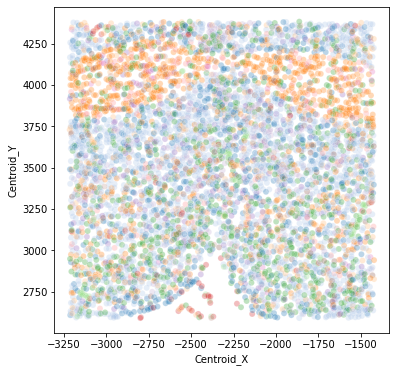

0.11 5799
0.21 5578
0.06 6144
0.16 6067
-0.09 6185
-0.14 6605
-0.19 6507
-0.24 6412
-0.29 6509
0.01 6111
-0.04 6154
2 (69039, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, -0.09, -0.14, -0.19, -0.24, -0.29, 0.01, -0.04}
0.26 5280


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


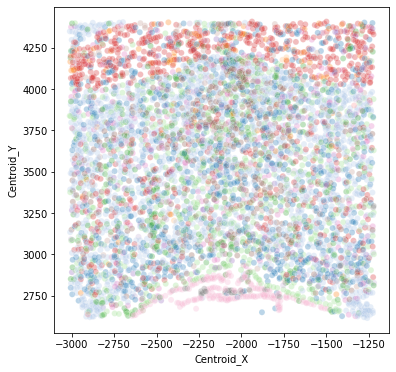

0.11 5727
0.21 5361
0.06 5381
0.16 5284
-0.09 5819
-0.14 6135
-0.19 6328
-0.24 6263
-0.29 6091
0.01 5677
-0.04 5693
3 (34289, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, 0.01}
0.26 5331


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


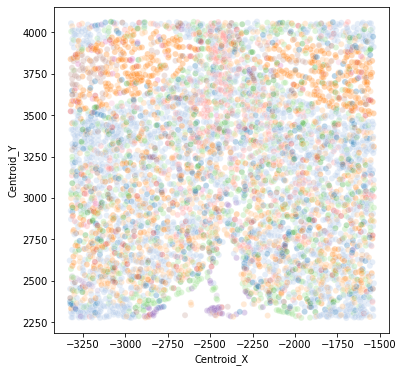

0.11 5889
0.21 5451
0.06 6058
0.16 5736
0.01 5824
4 (28365, 170)
{-0.14, -0.19, -0.29, -0.09, -0.04}
-0.14 6036
-0.19 5694
-0.29 6236
-0.09 4689
-0.04 5710
5 (33569, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, 0.01}
0.26 5457


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


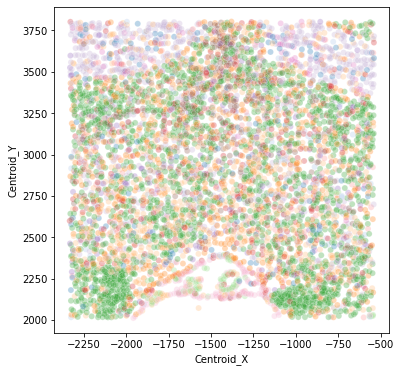

0.11 5765
0.21 5228
0.06 5329
0.16 5839
0.01 5951
6 (31564, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, 0.01}
0.26 4661


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


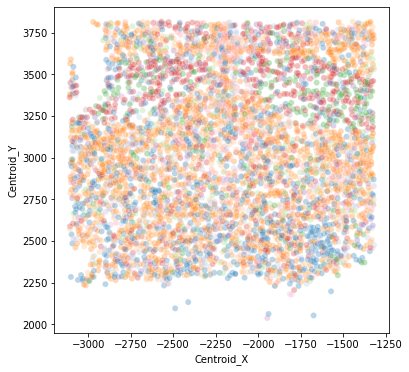

0.11 5429
0.21 5285
0.06 5491
0.16 5143
0.01 5555
7 (70498, 170)
{0.26, 0.11, 0.21, 0.06, 0.16, -0.09, -0.14, -0.19, -0.24, -0.29, 0.01, -0.04}
0.26 5905


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


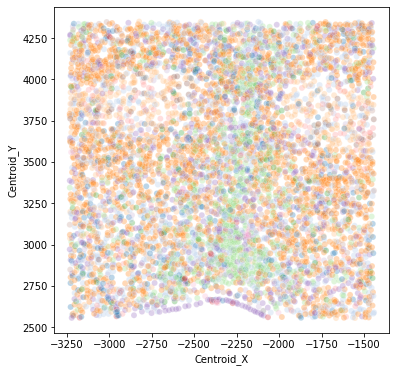

0.11 6000
0.21 5862
0.06 5423
0.16 5780
-0.09 5954
-0.14 5939
-0.19 5881
-0.24 5986
-0.29 5912
0.01 5862
-0.04 5994
8 (36316, 170)
{-0.14, -0.24, -0.19, -0.09, -0.29, -0.04}
-0.14 5970
-0.24 5983
-0.19 6011
-0.09 6417
-0.29 5452
-0.04 6483
9 (37491, 170)
{-0.14, -0.24, -0.19, -0.09, -0.29, -0.04}
-0.14 6215
-0.24 6398
-0.19 6231
-0.09 6200
-0.29 6342
-0.04 6105
10 (35178, 170)
{-0.14, -0.24, -0.19, -0.09, -0.29, -0.04}
-0.14 5769
-0.24 6176
-0.19 5775
-0.09 6051
-0.29 5381
-0.04 6026
11 (35693, 170)
{-0.14, -0.24, -0.19, -0.09, -0.29, -0.04}
-0.14 6105
-0.24 5811
-0.19 5722
-0.09 6101
-0.29 5779
-0.04 6175
12 (22698, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5787


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


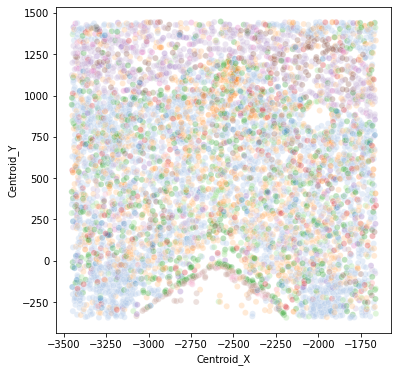

0.11 5653
0.21 5410
0.16 5848
13 (21590, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5726


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


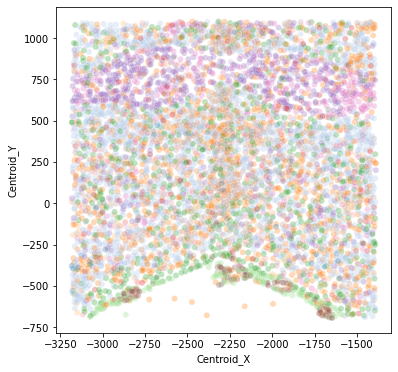

0.11 5556
0.21 5403
0.16 4905
14 (22439, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5434


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


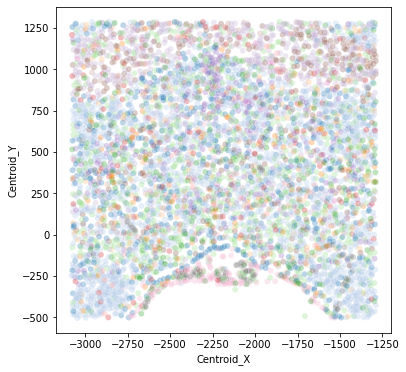

0.11 5790
0.21 5652
0.16 5563
15 (22374, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5206


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


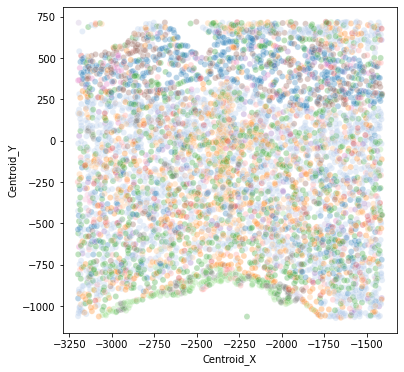

0.11 5880
0.21 5669
0.16 5619
16 (21929, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5323


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


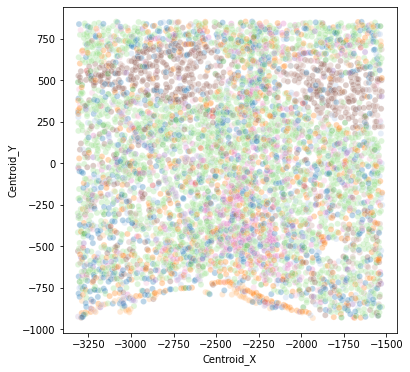

0.11 5711
0.21 5391
0.16 5504
17 (20979, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 4828


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


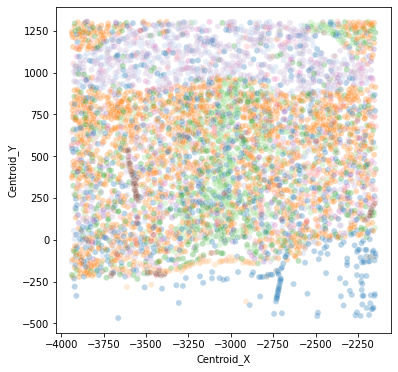

0.11 5417
0.21 5373
0.16 5361
18 (23068, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5555


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


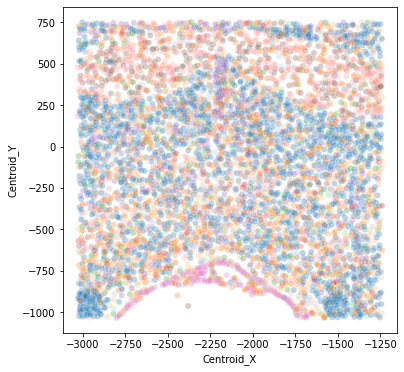

0.11 5665
0.21 5881
0.16 5967
19 (20926, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 4807


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


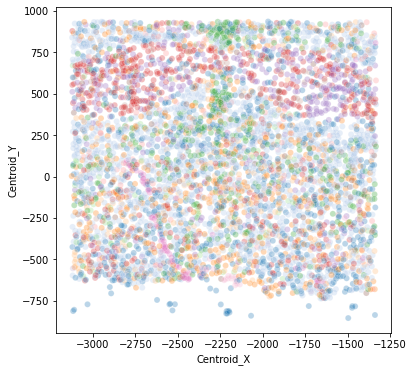

0.11 5533
0.21 5194
0.16 5392
20 (21993, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5696


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


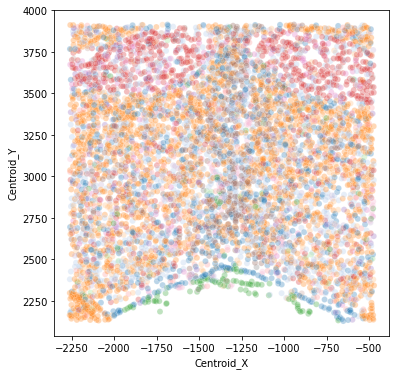

0.11 5283
0.21 5394
0.16 5620
21 (21210, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5770


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


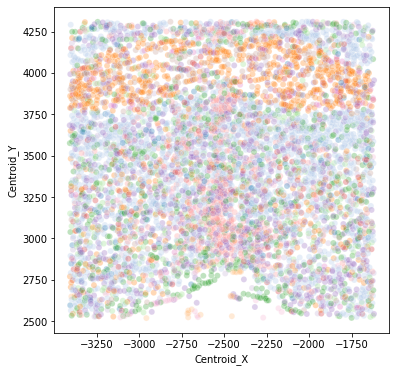

0.11 4877
0.21 5434
0.16 5129
22 (22284, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5956


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


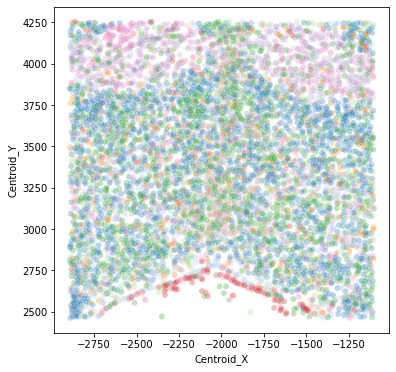

0.11 5624
0.21 5492
0.16 5212
23 (22293, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5384


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


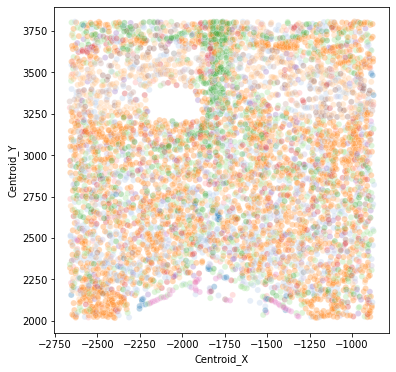

0.11 5857
0.21 5603
0.16 5449
24 (21325, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5017


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


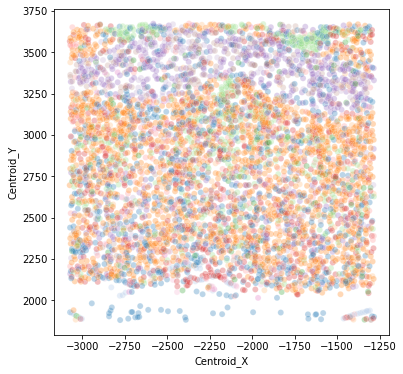

0.11 5606
0.21 5334
0.16 5368
25 (22384, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5261


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


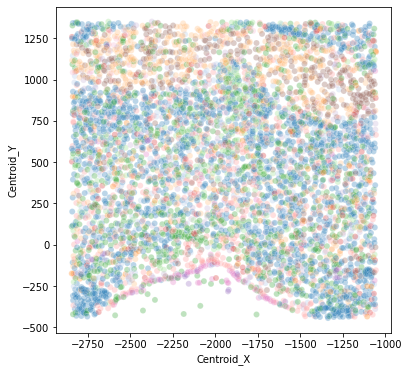

0.11 5939
0.21 5223
0.16 5961
26 (23081, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5468


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


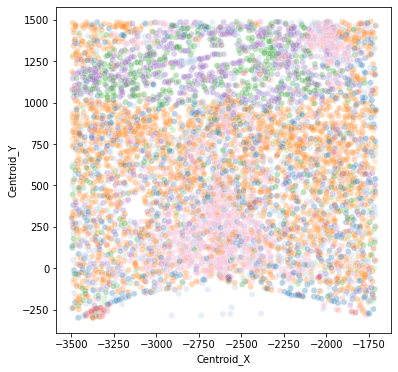

0.11 5844
0.21 5882
0.16 5887
27 (10291, 170)
{0.16, 0.11}
0.16 5141
0.11 5150
28 (21941, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5476


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


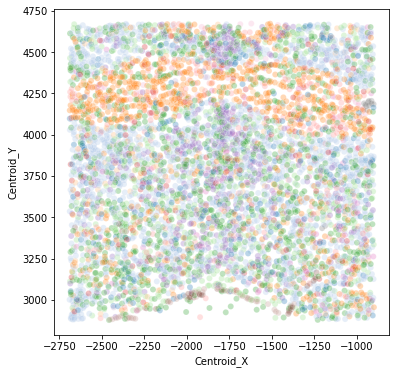

0.11 5676
0.21 5190
0.16 5599
29 (22647, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5511


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


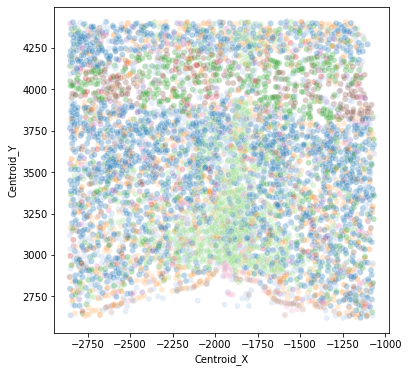

0.11 5877
0.21 5444
0.16 5815
30 (22347, 170)
{0.26, 0.11, 0.21, 0.16}
0.26 5425


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


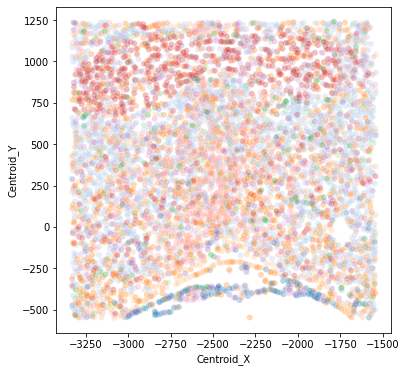

0.11 5754
0.21 5660
0.16 5508


In [5]:
# Plot all 0.26
for animal_id in range(1, 31):
    fish_pd_sub = fish_pd.loc[fish_pd['Animal_ID'] == animal_id, :]
    print(animal_id, fish_pd_sub.shape)
    print(set(fish_pd_sub['Bregma'].values))
    for bregma in list(set(fish_pd_sub['Bregma'].values)):
        print(bregma, np.sum(fish_pd_sub['Bregma'].values == bregma))
        
        if bregma == 0.26:
            import seaborn as sns
            plt.figure(figsize=(6, 6))
            _fish_pd_sub = fish_pd.loc[np.logical_and(fish_pd['Animal_ID'] == animal_id, fish_pd['Bregma'] == bregma), :]
            sns.scatterplot(_fish_pd_sub['Centroid_X'], _fish_pd_sub['Centroid_Y'], hue=_fish_pd_sub['Cell_class'], palette='tab20', 
                           legend=False, alpha=0.3)
            plt.show()
        

# Check the data which contains 5665 cells

In [4]:
fish_pd_sub = fish_pd.loc[np.logical_and(fish_pd['Animal_ID'] == 18, fish_pd['Bregma'] == 0.26), :]
fish_pd_sub

,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,Ace2,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
528565,e9d73818-5233-41aa-b387-25257543d9de,18,Female,Parenting,0.26,-3022.004661,-913.436388,Inhibitory,I-17,0.000000,...,0.000000,0.000000,0.785172,0.000000,0.252832,0.000000,0.000000,0.000000,0.000000,0.301008
528566,704470b6-2455-4e8d-be4c-6337b017efd0,18,Female,Parenting,0.26,-3020.644809,-999.326928,Inhibitory,I-17,0.000000,...,0.053157,0.000000,0.954474,0.022710,0.551244,0.000000,0.000000,0.000000,0.029035,0.054919
528567,16b60d1b-e1b9-40e3-bd99-848f2c03047a,18,Female,Parenting,0.26,-3017.659617,-981.643872,Inhibitory,I-17,0.000000,...,0.043167,0.000000,1.025583,0.013712,0.781845,0.000000,0.000000,0.000000,0.029430,0.000000
528568,f5346407-1501-407d-b981-445f46023b16,18,Female,Parenting,0.26,-3016.583112,-968.216564,Inhibitory,I-17,0.000000,...,0.000000,0.000000,0.685039,0.000000,0.114975,0.000000,0.000000,0.000000,0.029108,0.000000
528569,b1ab923f-d5fd-4eff-99d3-76bb333db9b2,18,Female,Parenting,0.26,-3014.546591,-951.946364,Inhibitory,I-17,0.000000,...,3.289237,0.000000,0.662800,0.015281,0.000000,0.000000,0.000000,0.000000,0.027072,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534115,331a482f-2b97-46d0-999f-bddc91395d51,18,Female,Parenting,0.26,-1265.441740,355.801633,OD Mature 1,NaN,0.000000,...,0.013043,0.000000,0.000000,0.015949,0.000000,0.004345,0.019068,0.020962,0.007964,0.000000
534116,1dc07ac5-7713-4851-81e7-82190dd4ad81,18,Female,Parenting,0.26,-1250.715157,359.731530,OD Mature 1,NaN,0.000000,...,0.010604,0.012548,0.000000,0.019167,0.005378,0.000000,0.000000,0.031773,0.007725,0.000000
534117,b548b5c3-4286-4426-b95a-2afe715420f7,18,Female,Parenting,0.26,-1371.312903,555.380588,Inhibitory,I-1,0.825408,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031846
534118,2d19a0f3-2196-41ab-8ed7-486fca9db40b,18,Female,Parenting,0.26,-1328.568020,559.434964,Inhibitory,I-1,0.000000,...,0.000000,0.000000,0.215245,0.000000,0.051812,0.065958,0.074774,0.000000,0.001262,0.097569


/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


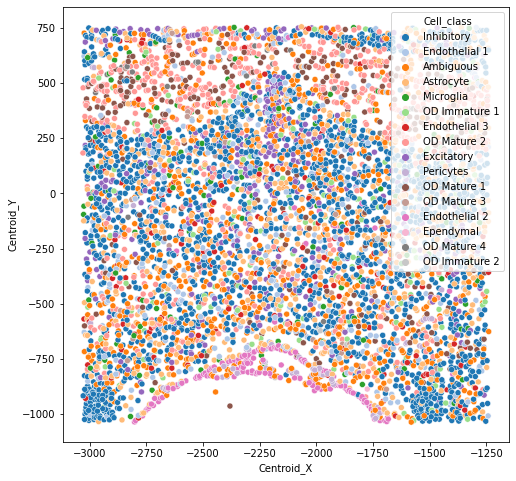

In [5]:
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(fish_pd_sub['Centroid_X'], fish_pd_sub['Centroid_Y'], hue=fish_pd_sub['Cell_class'], palette='tab20')
# plt.xlim(2000, 2500)
# plt.ylim(-2500, -2000)
plt.show()


# Create pseudo image

/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


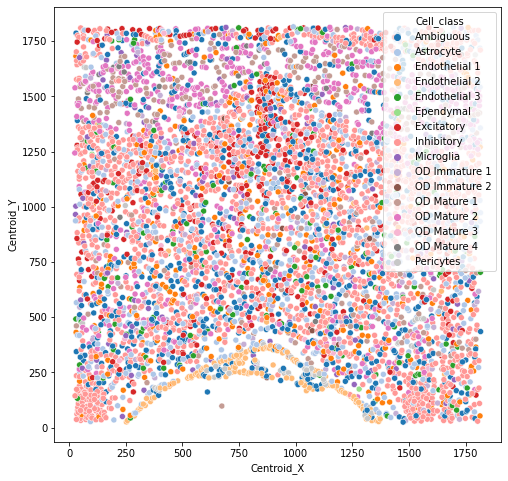

In [6]:
mydata = fish_pd_sub.copy()
mydata.loc[:, 'Centroid_X'] = fish_pd_sub.loc[:, 'Centroid_X'] - (np.min(fish_pd_sub.loc[:, 'Centroid_X']) - 25)
mydata.loc[:, 'Centroid_Y'] = fish_pd_sub.loc[:, 'Centroid_Y'] - (np.min(fish_pd_sub.loc[:, 'Centroid_Y']) - 25)
plt.figure(figsize=(8, 8))
hue_order = list(set(mydata['Cell_class'].values))
hue_order.sort()
sns.scatterplot(mydata['Centroid_X'], mydata['Centroid_Y'], hue=mydata['Cell_class'], palette='tab20', 
               hue_order=hue_order)
plt.show()

In [7]:
from scipy.spatial import distance_matrix
d = distance_matrix(fish_pd_sub.loc[:, ['Centroid_X', 'Centroid_Y']], fish_pd_sub.loc[:, ['Centroid_X', 'Centroid_Y']])

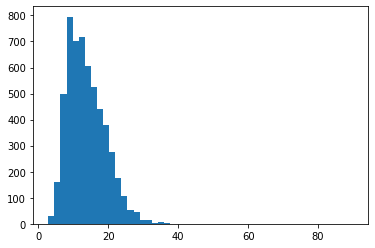

In [8]:
# Explore cell-cell distance
d[d == 0] = np.nan
plt.hist(np.nanmin(d, axis=0), bins=50)
plt.show()

In [12]:
# Cell diameter: 20um ~ 5 pixel
# Zoom in 4x: 20um ~ 20 pixel, 1um/pixel, cell radius 13 pixels
# Zoom in 5x: 20um ~ 25 pixel, 0.8um/pixel, cell radius 13 pixels
# Zoom in 10x: 20um ~ 50 pixel, 0.4um/pixel, cell radius 25 pixels
IMAGE_WIDTH = int(np.max(mydata.loc[:, 'Centroid_X']) * 4 + 125)  # was 5
IMAGE_HEIGHT = int(np.max(mydata.loc[:, 'Centroid_Y']) * 4 + 125)
print(IMAGE_HEIGHT, IMAGE_WIDTH)
pseudo_image = np.zeros([IMAGE_HEIGHT, IMAGE_WIDTH]) + 1

7386 7388


In [13]:
mydata.index = np.arange(len(mydata)) + 2
for index in mydata.index.values:
    x = int(np.round(mydata.loc[index, 'Centroid_X'] * 4)) 
    y = int(np.round(mydata.loc[index, 'Centroid_Y'] * 4)) 
    cell_type = mydata.loc[index, 'Cell_class']
    cell_type_index = np.argmax(np.array(hue_order) == cell_type)
    # pseudo_image[y, x] = sns.color_palette('tab20')[cell_type_index]
    pseudo_image[y, x] = index

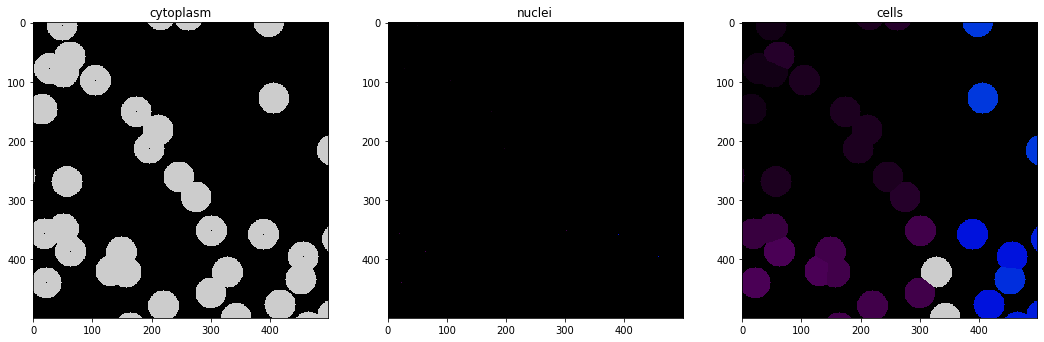

Time used: 400.8466463088989


In [15]:

import skimage
import time
from scipy import ndimage as ndi
import skimage.morphology

def enlarge(nuclei_seg, radius=5, show_process=False):
    '''
    Args:
        nuclei_seg: output of cytof_nuclei_segmentation, [h, w], background = 1
    '''
    markers = nuclei_seg.copy()
    mask = nuclei_seg > 1
    unknown = mask.copy()
    unknown = np.logical_xor(skimage.morphology.dilation(unknown, skimage.morphology.disk(radius)), mask)
    markers[unknown] = 0
    if show_process:
        plt.figure(figsize=(18, 6))
        plt.subplot(131)
        plt.title('cytoplasm')
        # plt.imshow(unknown[0:150, 0:150], cmap=plt.cm.nipy_spectral, interpolation='nearest')
        plt.imshow(unknown[550:1050, 550:1050], cmap=plt.cm.nipy_spectral, interpolation='nearest')

    # watershed
    distance = ndi.distance_transform_edt(markers <= 1)  # Calculate distance for True pixels
    labels = skimage.morphology.watershed(distance, markers)
    # labels = skimage.morphology.watershed(np.zeros_like(markers), markers)
    if show_process:
        plt.subplot(132)
        plt.title('nuclei')
        # plt.imshow(nuclei_seg[0:150, 0:150], cmap=plt.cm.nipy_spectral, interpolation='nearest')
        plt.imshow(nuclei_seg[550:1050, 550:1050], cmap=plt.cm.nipy_spectral, interpolation='nearest')
        plt.subplot(133)
        plt.title('cells')
        # plt.imshow(labels[0:150, 0:150], cmap=plt.cm.nipy_spectral, interpolation='nearest')
        plt.imshow(labels[550:1050, 550:1050], cmap=plt.cm.nipy_spectral, interpolation='nearest')
        plt.show()
    return labels

start = time.time()
pseudo_image = enlarge(pseudo_image, radius=13*2, show_process=True)
print("Time used: {}".format(time.time() - start))


In [16]:
mydata.to_csv("./Sample_data/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_v2.csv")

In [ ]:

import torch
torch.save(pseudo_image, "./output/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_pseuso_image_v2.pt")


In [18]:
import torch
pseudo_image = torch.load("./output/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_pseuso_image_v2.pt")

In [19]:
pseudo_image

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=int32)

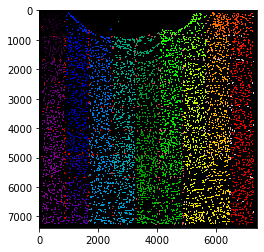

In [20]:
plt.imshow(pseudo_image, cmap=plt.cm.nipy_spectral, interpolation='nearest')
plt.show()

# Explore count stat

In [17]:
gene_names = mydata.columns.values[9:]
count_stat = pd.DataFrame(columns=gene_names, index=["mean", "std", "tile_95", "non_zero_p", "max"])
count_stat.loc['mean', :] = np.average(mydata.loc[:, gene_names], axis=0)
count_stat.loc['std', :] = np.std(mydata.loc[:, gene_names], axis=0)
count_stat.loc['tile_95', :] = np.quantile(mydata.loc[:, gene_names], 0.95, axis=0)
count_stat.loc['non_zero_p', :] = np.sum(np.array(mydata.loc[:, gene_names]) > 0, axis=0)/mydata.loc[:, gene_names].shape[0]
count_stat.loc['max', :] = np.max(mydata.loc[:, gene_names], axis=0)

In [18]:
count_stat

,Ace2,Adora2a,Aldh1l1,Amigo2,Ano3,Aqp4,Ar,Arhgap36,Avpr1a,Avpr2,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
mean,0.285003,0.333082,3.33785,1.13923,0.609093,5.36105,2.03497,1.12407,0.299069,0.18769,...,0.0792511,0.0397139,0.267187,0.0503993,0.0413017,0.0322474,0.0594921,0.0209055,0.00825943,0.127121
std,1.10452,1.62481,6.41814,2.53594,2.00726,12.728,3.84495,3.34787,0.832009,0.581807,...,0.375583,0.147788,0.418041,0.463738,0.128532,0.251429,0.441142,0.0762736,0.0403538,0.388706
tile_95,1.55366,1.69131,17.2743,5.50688,3.21229,29.6253,9.83554,5.0488,1.83813,1.25604,...,0.498994,0.250686,1.11455,0.0568019,0.197411,0.0643381,0.21093,0.0579078,0.0273405,0.729005
non_zero_p,0.158056,0.144014,0.545635,0.371017,0.219982,0.540954,0.440504,0.350675,0.183798,0.145095,...,0.227183,0.1991,0.529973,0.522592,0.329433,0.60288,0.537714,0.522412,0.50153,0.326733
max,27.0543,60.2209,139.475,41.55,36.2049,179.053,40.6486,61.6902,11.5199,8.9275,...,11.5372,2.94903,3.64697,14.209,1.44186,10.2099,31.5987,3.8818,2.06966,7.08965


(array([5.174e+03, 1.610e+02, 1.130e+02, 5.300e+01, 3.000e+01, 1.600e+01,
        4.000e+00, 3.000e+00, 0.000e+00, 1.000e+00]),
 array([0.        , 0.36481414, 0.72962829, 1.09444243, 1.45925657,
        1.82407072, 2.18888486, 2.553699  , 2.91851315, 3.28332729,
        3.64814143]),
 <BarContainer object of 10 artists>)

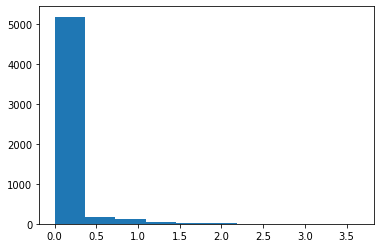

In [19]:
plt.hist(np.log2(mydata.loc[:, 'Penk'] + 1))

In [133]:
count_stat.to_csv("./output/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_count_stat.csv")

# Session Info

In [37]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2021.5.30
chardet==3.0.4
charset-normalizer==2.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
fastcluster==1.2.4
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==3.2
image-registration==0.2.4
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel